# NPU/GPU MatMul Profiling

In [2]:
xpu_result_path = "./mm_const_right_xpu2_fp16"
gpu_npu_result_path = "./mm_const_right_gpu_npu_fp16"

def parse_result(result_path):
    results = {}
    with open(result_path, "r") as f:
        lines = f.readlines()
        for line in lines:
            items = [item.strip() for item in line.split(",")]
            # 预期 18 列数据: K, M, N, pct, outlining, arithmetic_intensity,
            # gpu_compile, npu_compile, gpu_runtime, npu_runtime, xpu_runtime, xgpu_runtime, xnpu_runtime,
            # gpu_throughput, npu_throughput, xpu_throughput, xgpu_throughput, xnpu_throughput
            assert len(items) == 19, f"Expected 19 columns, got {len(items)}: {line}"
            shape_key = (int(items[0]), int(items[1]), int(items[2]), float(items[3]))
            arithmetic_intensity = float(items[6])
            gpu_compile = int(items[7])
            npu_compile = int(items[8])
            gpu_runtime = int(items[9])
            npu_runtime = int(items[10])
            xpu_runtime = int(items[11])
            gpu_throughput = float(items[14])
            npu_throughput = float(items[15])
            xpu_throughput = float(items[16])
            results[shape_key] = (arithmetic_intensity, gpu_compile, npu_compile,
                                  gpu_runtime, npu_runtime, xpu_runtime,
                                  gpu_throughput, npu_throughput, xpu_throughput)
    return results

def parse_result2(result_path):
    results = {}
    with open(result_path, "r") as f:
        lines = f.readlines()
        for line in lines:
            items = [item.strip() for item in line.split(",")]
            # 预期 18 列数据: K, M, N, pct, outlining, arithmetic_intensity,
            # gpu_compile, npu_compile, gpu_runtime, npu_runtime, xpu_runtime, xgpu_runtime, xnpu_runtime,
            # gpu_throughput, npu_throughput, xpu_throughput, xgpu_throughput, xnpu_throughput
            assert len(items) == 18, f"Expected 18 columns, got {len(items)}: {line}"
            shape_key = (int(items[0]), int(items[1]), int(items[2]), float(items[3]))
            arithmetic_intensity = float(items[5])
            gpu_compile = int(items[6])
            npu_compile = int(items[7])
            gpu_runtime = int(items[8])
            npu_runtime = int(items[9])
            xpu_runtime = int(items[10])
            xgpu_runtime = int(items[11])
            xnpu_runtime = int(items[12])
            gpu_throughput = float(items[13])
            npu_throughput = float(items[14])
            xpu_throughput = float(items[15])
            xgpu_throughput = float(items[16])
            xnpu_throughput = float(items[17])
            results[shape_key] = (arithmetic_intensity, gpu_compile, npu_compile,
                                  gpu_runtime, npu_runtime, xpu_runtime, xgpu_runtime, xnpu_runtime,
                                  gpu_throughput, npu_throughput, xpu_throughput, xgpu_throughput, xnpu_throughput)
    return results

xpu_results = parse_result(xpu_result_path)
gpu_npu_results = parse_result2(gpu_npu_result_path)

# (8192, 4096, 4096)
keys1 = [(8192, 4096, 4096, i/40.0) for i in range(0, 40)]
xpu_data1 = [xpu_results[key] for key in keys1 if key in xpu_results]
gpu_npu_data1 = [gpu_npu_results[key] for key in keys1 if key in gpu_npu_results]


## Compile time
### [k, 4096] * [4096, 4096] and [4096, 4096] * [4096, k]

In [4]:
import matplotlib.pyplot as plt
import numpy as np    

x = [k[0] for k in keys1]
npu_y1 = [d[0] for d in npu_data1]
gpu_y1 = [d[0] for d in gpu_data1]

# plot a line chart with common x and four lines with each y data
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, npu_y1, label='NPU (k, 4096, 4096)')
ax.plot(x, gpu_y1, label='GPU (k, 4096, 4096)')

ax.set_xlabel('k')
ax.set_ylabel('Compile Time (us)')
ax.legend()
plt.show()

NameError: name 'npu_data1' is not defined

### [k, 4096] * [4096, 11008] and [11008, 4096] * [4096, k]

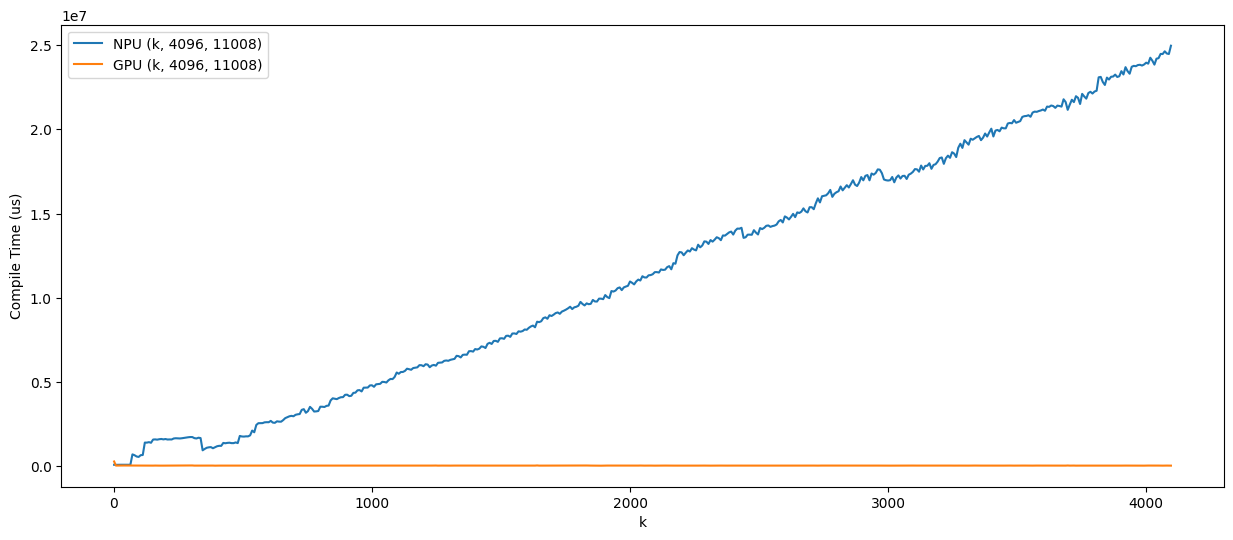

In [5]:
x = [k[0] for k in keys3]
npu_y1 = [d[0] for d in npu_data3]
gpu_y1 = [d[0] for d in gpu_data3]
# plot a line chart with common x and four lines with each y data
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, npu_y1, label='NPU (k, 4096, 11008)')
ax.plot(x, gpu_y1, label='GPU (k, 4096, 11008)')
ax.set_xlabel('k')
ax.set_ylabel('Compile Time (us)')
ax.legend()
plt.show()

## Runtime
### [k, 4096] * [4096, 4096]

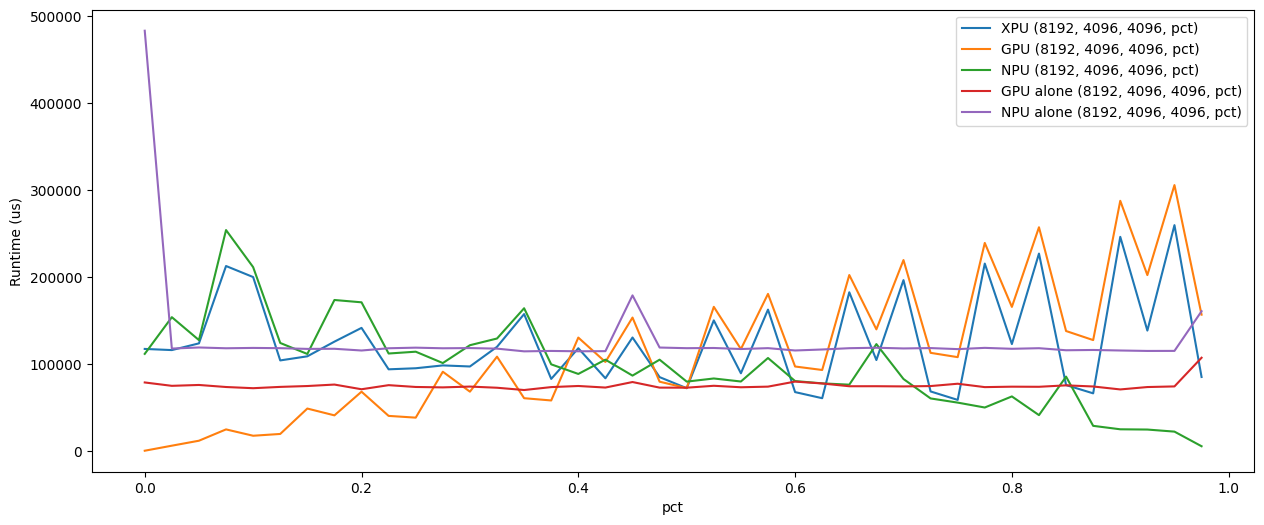

In [4]:
import matplotlib.pyplot as plt
import numpy as np    
x = [k[3] for k in keys1]
xpu_y1 = [d[5] for d in xpu_data1]
gpu_y1 = [d[6] for d in gpu_npu_data1]
npu_y1 = [d[7] for d in gpu_npu_data1]

gpu_y2 = [d[3] for d in gpu_npu_data1]
npu_y2 = [d[4] for d in gpu_npu_data1]

# plot a line chart with common x and four lines with each y data
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, xpu_y1, label='XPU (8192, 4096, 4096, pct)')
ax.plot(x, gpu_y1, label='GPU (8192, 4096, 4096, pct)')
ax.plot(x, npu_y1, label='NPU (8192, 4096, 4096, pct)')
ax.plot(x, gpu_y2, label='GPU alone (8192, 4096, 4096, pct)')
ax.plot(x, npu_y2, label='NPU alone (8192, 4096, 4096, pct)')
ax.set_xlabel('pct')
ax.set_ylabel('Runtime (us)')
ax.legend()
plt.show()

## Throughput (TOPS)
### [1024, 4096] * [4096, 4096]

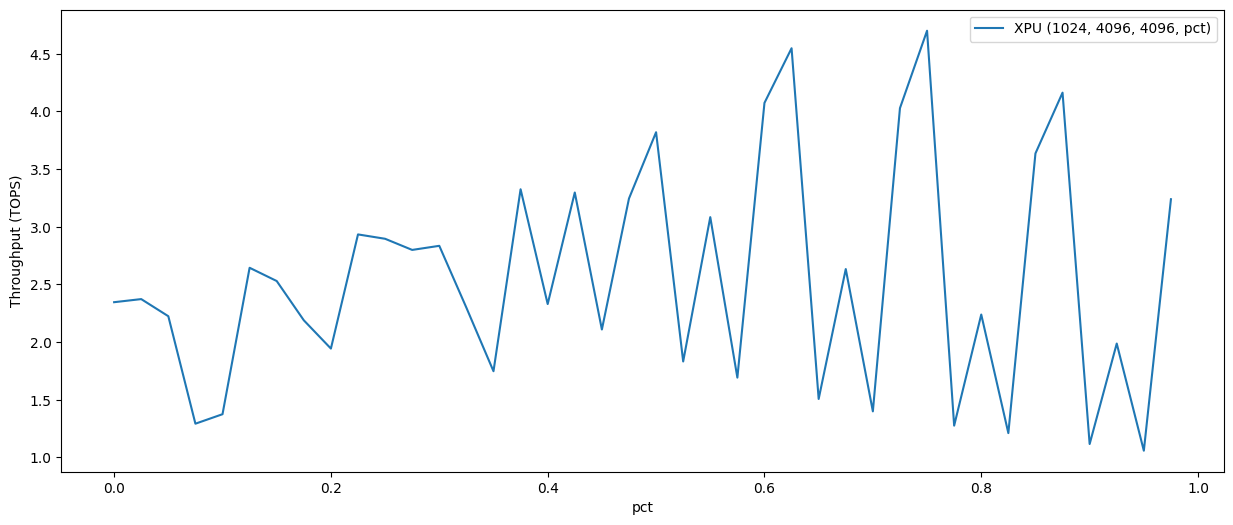

In [5]:
xpu_y1 = [d[8] for d in xpu_data1]

fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, xpu_y1, label='XPU (1024, 4096, 4096, pct)')

ax.set_xlabel('pct')
ax.set_ylabel('Throughput (TOPS)')
ax.legend()
plt.show()